In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt

grid_features = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_final_feature_set.csv")
grid_full = pd.read_csv(r"C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\grid_data_final_preprocessed_15min.csv")

grid_features = grid_features.reset_index(drop=True)
grid_full = grid_full.reset_index(drop=True)

In [3]:
# Calculate Z-Score
grid_features['net_load_zscore'] = zscore(grid_features['net_load_mw'])

threshold = 2.5
grid_features['zscore_anomaly'] = grid_features['net_load_zscore'].abs() > threshold

grid_full['zscore_anomaly'] = grid_features['zscore_anomaly']
grid_full['net_load_zscore'] = grid_features['net_load_zscore']

total_points = len(grid_full)
total_anomalies = grid_full['zscore_anomaly'].sum()

print("\nTotal data points:", total_points)
print("Total anomalies detected:", total_anomalies)
print("Percentage anomalies:", (total_anomalies/total_points)*100)


Total data points: 105216
Total anomalies detected: 1607
Percentage anomalies: 1.5273342457420924


In [ ]:
grid_features['ramp_zscore'] = zscore(grid_features['net_load_ramp'].fillna(method = "bfill"))

threshold = 2.5

# High Z-Score of ramp -> sudden spikes
grid_full['is_critical_event'] = (
    (grid_features['net_load_zscore'].abs() > threshold) & 
    (grid_features['ramp_zscore'].abs() > threshold)
)


grid_full['ramp_zscore'] = grid_features['ramp_zscore']
critical_anomalies = grid_full[grid_full['is_critical_event']]

# Intersection -> system very close to blackout out of nowhere
print(f"Total Critical (Intersection) Events: {len(critical_anomalies)}")

Total Critical (Intersection) Events: 34


In [5]:
normal_days = grid_full[~grid_full['is_critical_event']]

comparison = pd.DataFrame({
    'Metric': ['Net Load (MW)', 'Solar Gen (MW)', 'Temp (C)', 'Ramp Rate'],
    'Normal Average': [
        normal_days['net_load_mw'].mean(),
        normal_days['solar_gen_mw'].mean(),
        normal_days['temp_c'].mean(),
        grid_features['net_load_ramp'].mean()
    ],
    'Shock Event Average': [
        critical_anomalies['net_load_mw'].mean(),
        critical_anomalies['solar_gen_mw'].mean(),
        critical_anomalies['temp_c'].mean(),
        critical_anomalies['net_load_ramp'].mean() 
    ]
})

print(comparison)

           Metric  Normal Average  Shock Event Average
0   Net Load (MW)    19250.729282         37148.166667
1  Solar Gen (MW)     3558.147693          1109.911765
2        Temp (C)       17.469539            25.637451
3       Ramp Rate       -0.005392          1757.617647


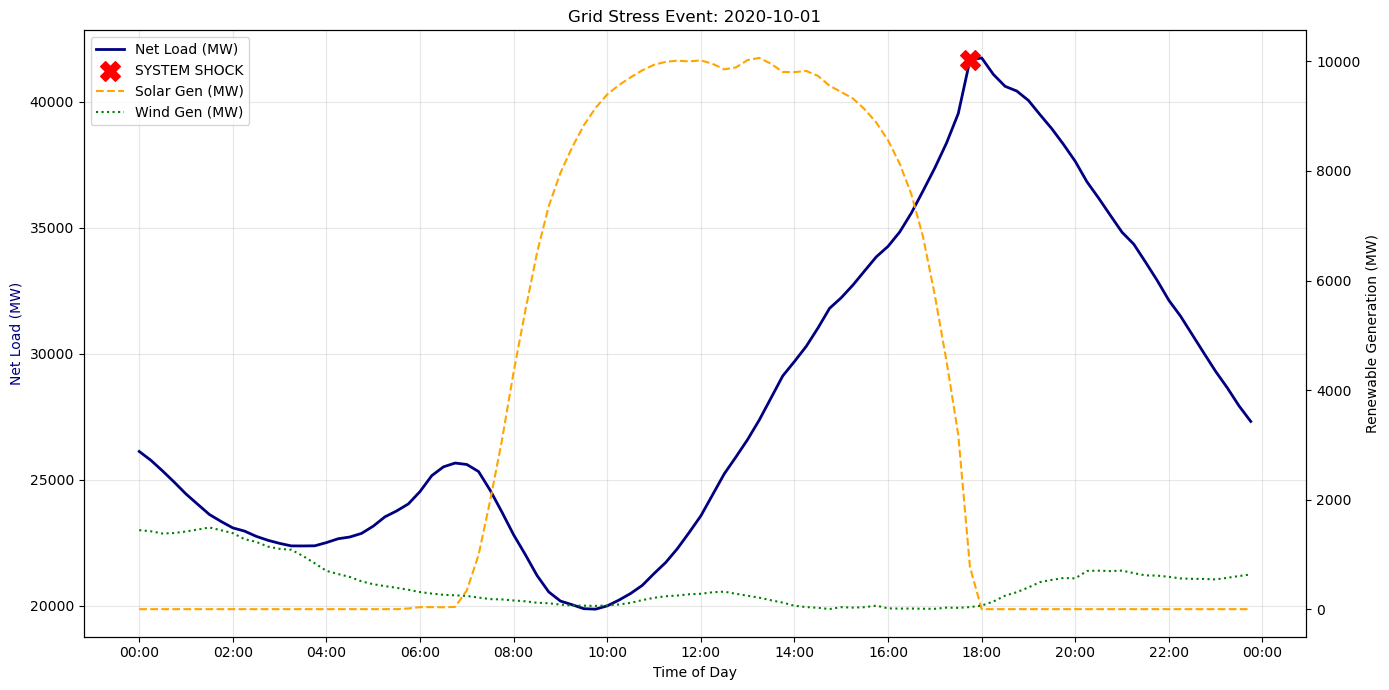

In [7]:
# The Worst Day
import matplotlib.dates as mdates
grid_full['timestamp'] = pd.to_datetime(grid_full['date'] + ' ' + grid_full['clock_time'])
worst_event = grid_full[grid_full['is_critical_event']].sort_values(
    'net_load_mw', ascending=False
).iloc[0]

worst_date = worst_event['date']

day_data = grid_full[grid_full['date'] == worst_date].copy()
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(
    day_data['timestamp'],
    day_data['net_load_mw'],
    color='navy',
    linewidth=2,
    label='Net Load (MW)'
)

ax1.scatter(
    worst_event['timestamp'],
    worst_event['net_load_mw'],
    color='red',
    s=200,
    marker='X',
    label='SYSTEM SHOCK',
    zorder=5
)

ax2 = ax1.twinx()

ax2.plot(
    day_data['timestamp'],
    day_data['solar_gen_mw'],
    color='orange',
    linestyle='--',
    label='Solar Gen (MW)'
)

ax2.plot(
    day_data['timestamp'],
    day_data['wind_gen_mw'],
    color='green',
    linestyle=':',
    label='Wind Gen (MW)'
)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))

ax1.set_xlabel("Time of Day")
ax1.set_ylabel("Net Load (MW)", color='navy')
ax2.set_ylabel("Renewable Generation (MW)")

plt.title(f"Grid Stress Event: {worst_date}")
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

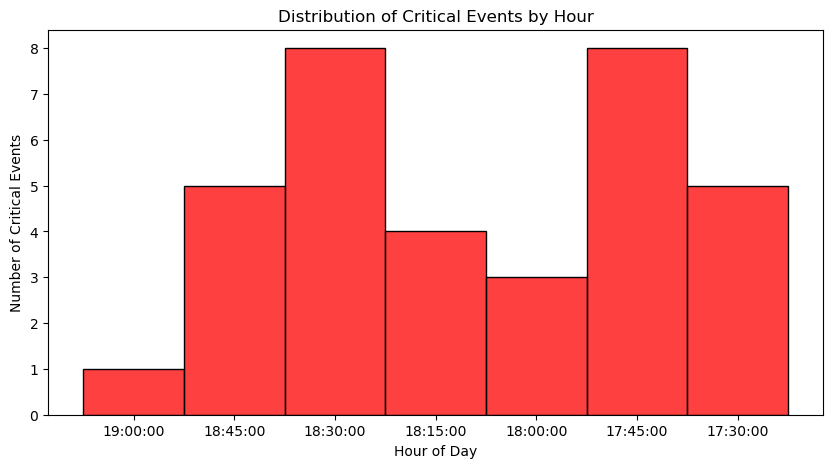

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Temporal Histogram 
plt.figure(figsize=(10, 5))
sns.histplot(data=critical_anomalies, x='clock_time', bins=24, color='red', kde=False)
plt.title("Distribution of Critical Events by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Critical Events")
plt.show()

In [9]:
critical_anomalies.columns

Index(['date', 'clock_time', 'holiday_name', 'season', 'day_of_week', 'temp_c',
       'humidity_pct', 'wind_speed_ms', 'ghi_wm2', 'dni_wm2', 'dhi_wm2',
       'solar_gen_mw', 'wind_gen_mw', 'demand_avg_mw', 'demand_max_mw',
       'demand_std_mw', 'hour_sin', 'hour_cos', 'demand_ramp', 'demand_lag_1h',
       'net_load_lag_24h', 'temp_rolling_3h', 'is_workday', 'sky_clearness',
       'demand_volatility_6h', 'solar_penetration', 'wind_penetration',
       'total_renewable_penetration', 'heat_index_c', 'demand_lag_24h',
       'demand_lag_168h', 'net_load_lag_1h', 'demand_lag_15min',
       'net_load_lag_15min', 'temp_lag_24h', 'temp_lag_48h',
       'solar_gen_lag_24h', 'wind_gen_lag_24h', 'demand_rolling_mean_7d',
       'demand_rolling_std_7d', 'demand_rolling_max_24h',
       'temp_rolling_mean_7d', 'temp_rolling_max_3d', 'solar_rolling_mean_7d',
       'wind_rolling_std_24h', 'cooling_degree_hours', 'heating_degree_hours',
       'cooling_dh_cumsum_7d', 'demand_percentile_rank',
 

C:\Users\Hp\AppData\Local\Temp\ipykernel_23140\4029345195.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  critical_anomalies['hour'] = pd.to_datetime(
C:\Users\Hp\AppData\Local\Temp\ipykernel_23140\4029345195.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  critical_anomalies['hour'] = pd.to_datetime(


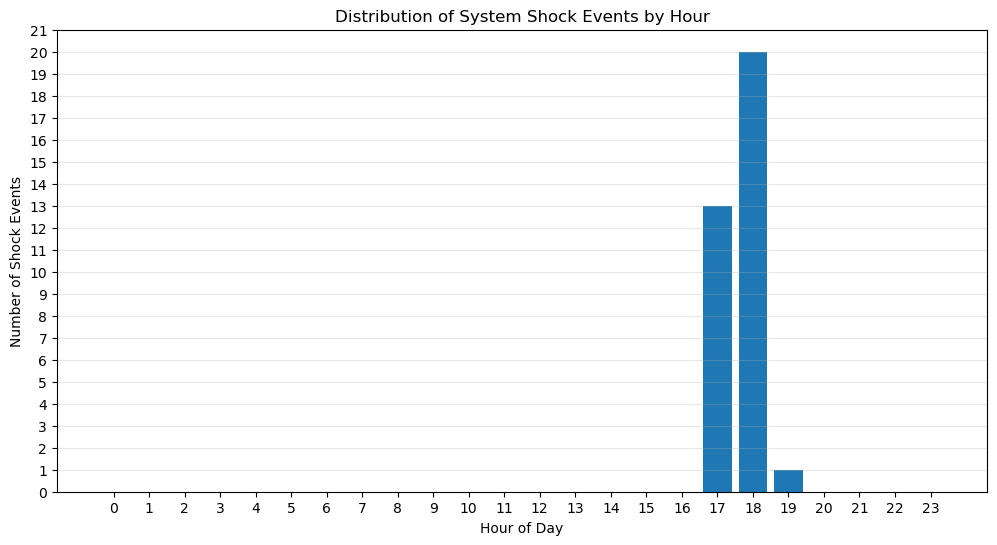

In [11]:
# Shocks per Hour
critical_anomalies['hour'] = pd.to_datetime(
    critical_anomalies['clock_time']
).dt.hour

shock_counts = critical_anomalies['hour'].value_counts().sort_index()
shock_counts = shock_counts.reindex(range(24), fill_value=0)

plt.figure(figsize=(12,6))
plt.bar(shock_counts.index, shock_counts.values)
plt.yticks(np.arange(0, shock_counts.max()+2, 1))
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Number of Shock Events")
plt.title("Distribution of System Shock Events by Hour")
plt.grid(axis='y', alpha=0.3)
plt.show()

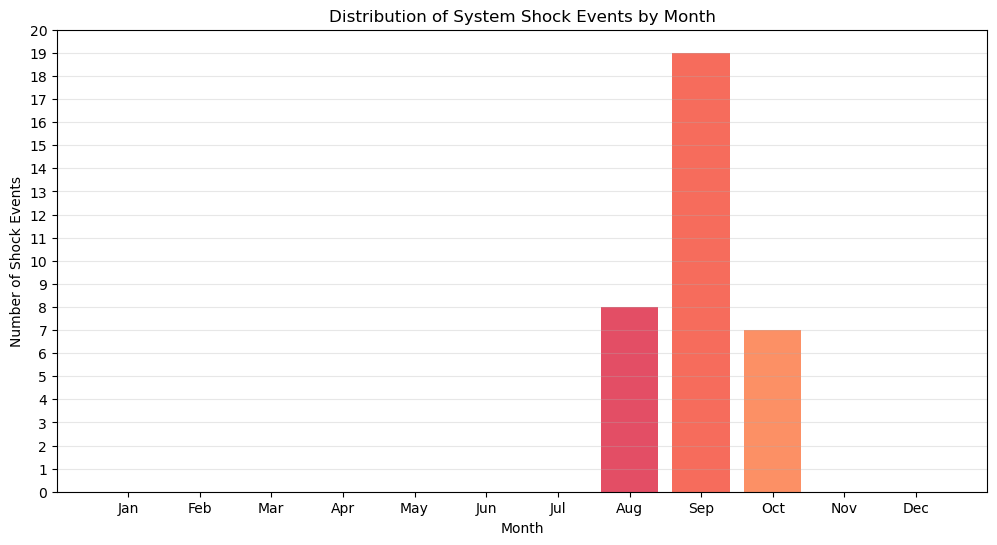

In [13]:
# Shock Events by Month
month_counts = critical_anomalies['month'].value_counts().sort_index()
month_counts = month_counts.reindex(range(1,13), fill_value=0)

colors = sns.color_palette("magma", 12)
plt.figure(figsize=(12,6))
plt.bar(month_counts.index, month_counts.values, color = colors)
plt.yticks(np.arange(0, month_counts.max()+2, 1))
month_labels = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]
plt.xticks(range(1,13), month_labels)
plt.xlabel("Month")
plt.ylabel("Number of Shock Events")
plt.title("Distribution of System Shock Events by Month")
plt.grid(axis='y', alpha=0.3)
plt.show()

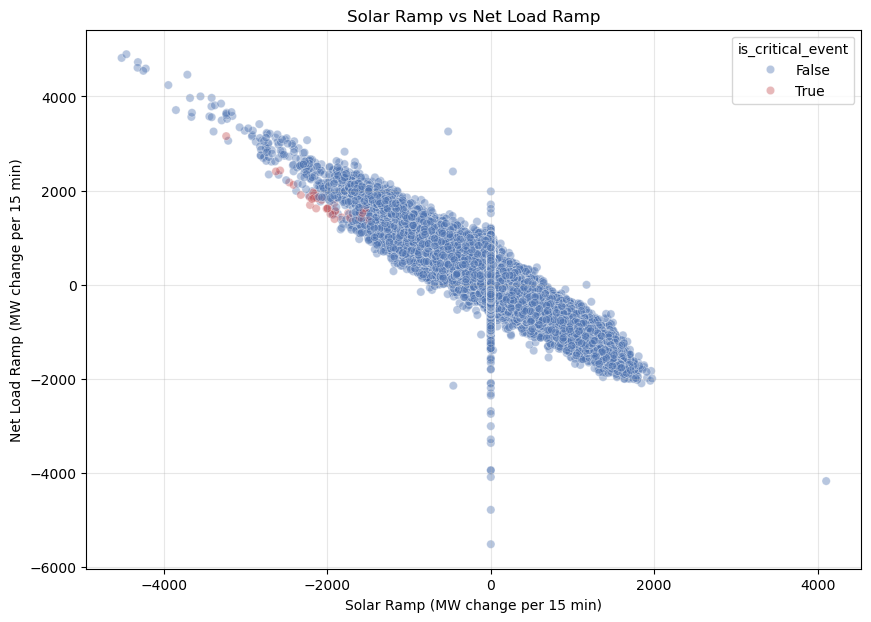

In [18]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=grid_full,
    x="solar_ramp",
    y="net_load_ramp",
    hue="is_critical_event",
    palette={False:"#4C72B0", True:"#C44E52"},
    alpha=0.4
)

plt.title("Solar Ramp vs Net Load Ramp")
plt.xlabel("Solar Ramp (MW change per 15 min)")
plt.ylabel("Net Load Ramp (MW change per 15 min)")
plt.grid(alpha=0.3)

plt.show()

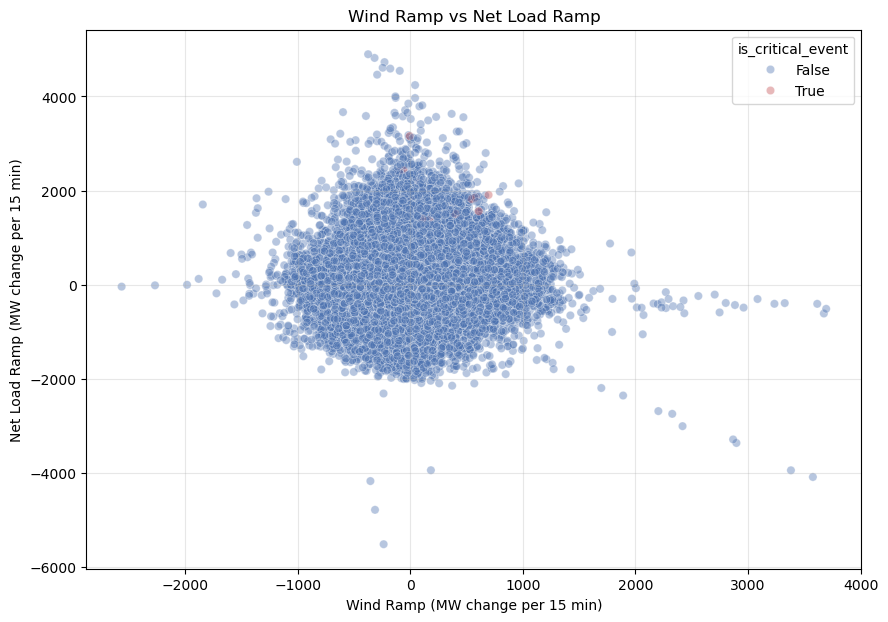

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=grid_full,
    x="wind_ramp",
    y="net_load_ramp",
    hue="is_critical_event",
    palette={False:"#4C72B0", True:"#C44E52"},
    alpha=0.4
)
plt.title("Wind Ramp vs Net Load Ramp")
plt.xlabel("Wind Ramp (MW change per 15 min)")
plt.ylabel("Net Load Ramp (MW change per 15 min)")
plt.grid(alpha=0.3)
plt.show()

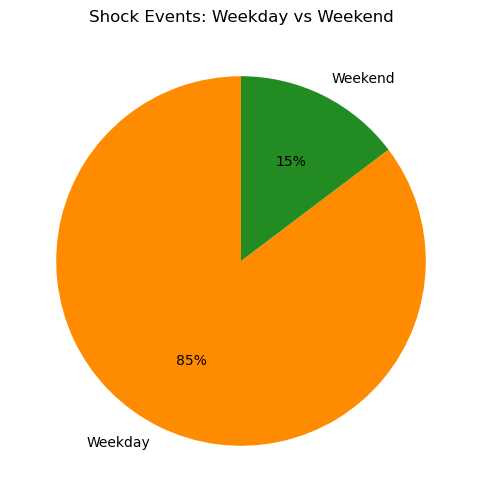

Weekday shocks: 29
Weekend shocks: 5


In [24]:
# Weekday vs Weekend
import matplotlib.pyplot as plt

# Remove any NaN values from the weekend flag
weekend_series = critical_anomalies['is_weekend'].dropna()

# Count weekday vs weekend events
weekday_count = (weekend_series == False).sum()
weekend_count = (weekend_series == True).sum()

values = [weekday_count, weekend_count]
labels = ['Weekday', 'Weekend']

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct='%1.0f%%',
    colors = ['darkorange', 'forestgreen'],
    startangle=90
)

plt.title("Shock Events: Weekday vs Weekend")

plt.show()

print("Weekday shocks:", weekday_count)
print("Weekend shocks:", weekend_count)

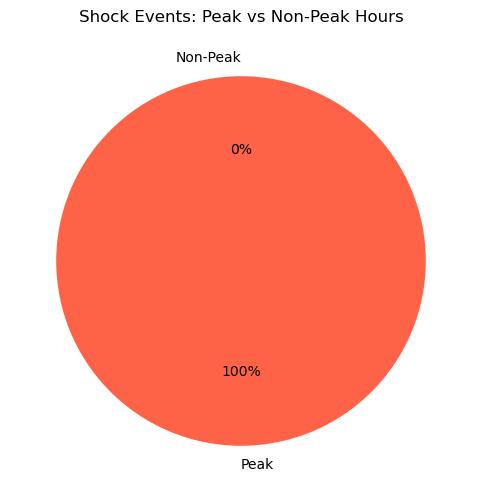

In [25]:
# Peak Hours
peak_series = critical_anomalies['is_peak_hour'].dropna()
peak_count = (peak_series == True).sum()
non_peak_count = (peak_series == False).sum()
values = [non_peak_count, peak_count]
labels = ['Non-Peak', 'Peak']

plt.figure(figsize=(6,6))
plt.pie(
    values,
    labels=labels,
    autopct='%1.0f%%',
    colors=['cornflowerblue', 'tomato'],
    startangle=90
)
plt.title("Shock Events: Peak vs Non-Peak Hours")
plt.show()

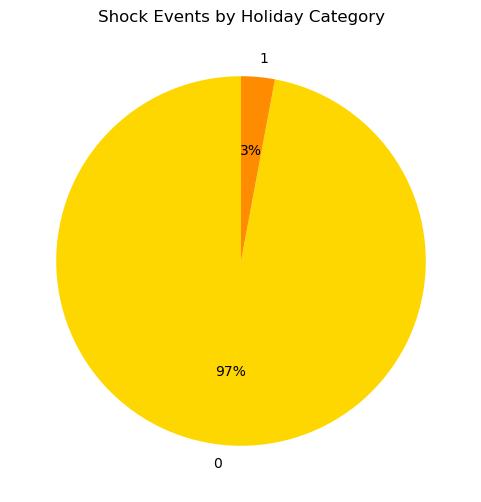

In [28]:
# Holiday
holiday_counts = critical_anomalies['is_holiday'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    holiday_counts.values,
    labels=holiday_counts.index,
    autopct='%1.0f%%',
    colors=['gold', 'darkorange', 'firebrick', 'steelblue'],
    startangle=90
)
plt.title("Shock Events by Holiday Category")
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_23140\2149097026.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  grid_full['hour'] = pd.to_datetime(grid_full['clock_time']).dt.hour


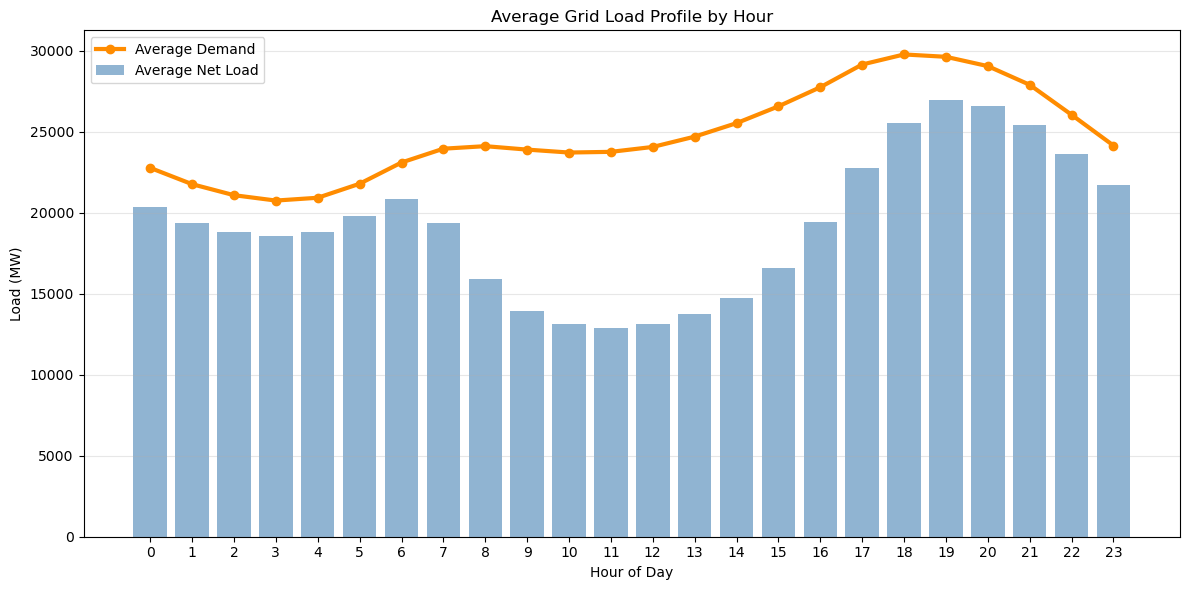

In [30]:
# Hourly Net Load vs Demand (Same Axis)

grid_full['hour'] = pd.to_datetime(grid_full['clock_time']).dt.hour

hourly_profile = grid_full.groupby('hour').agg({
    'net_load_mw':'mean',
    'demand_avg_mw':'mean'
}).reset_index()

plt.figure(figsize=(12,6))

plt.bar(
    hourly_profile['hour'],
    hourly_profile['net_load_mw'],
    color='steelblue',
    alpha=0.6,
    label='Average Net Load'
)

plt.plot(
    hourly_profile['hour'],
    hourly_profile['demand_avg_mw'],
    color='darkorange',
    linewidth=3,
    marker='o',
    label='Average Demand'
)

plt.xlabel("Hour of Day")
plt.ylabel("Load (MW)")
plt.title("Average Grid Load Profile by Hour")
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

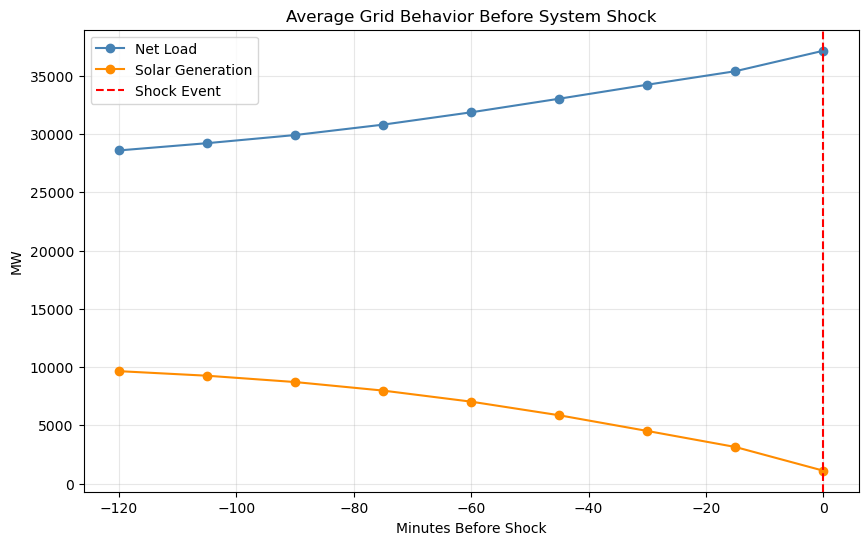

In [31]:
# Pre-shock trajectory analysis

window = 8 
shock_indices = grid_full.index[grid_full['is_critical_event']]

net_load_traj = []
solar_traj = []

for idx in shock_indices:

    if idx >= window:
        segment = grid_full.iloc[idx-window:idx+1]

        net_load_traj.append(segment['net_load_mw'].values)
        solar_traj.append(segment['solar_gen_mw'].values)

net_load_traj = np.array(net_load_traj)
solar_traj = np.array(solar_traj)

avg_net_load = net_load_traj.mean(axis=0)
avg_solar = solar_traj.mean(axis=0)

time_axis = np.arange(-120, 15, 15)

plt.figure(figsize=(10,6))

plt.plot(time_axis, avg_net_load, marker='o', label='Net Load', color='steelblue')
plt.plot(time_axis, avg_solar, marker='o', label='Solar Generation', color='darkorange')

plt.axvline(0, color='red', linestyle='--', label='Shock Event')

plt.xlabel("Minutes Before Shock")
plt.ylabel("MW")
plt.title("Average Grid Behavior Before System Shock")

plt.legend()
plt.grid(alpha=0.3)
plt.show()